# Aggregate the PREP tables

In [61]:
import geopandas as gpd
import pandas as pd

PATH_RAW = "../data/prep/"

# Loading all prep geojson tables

In [62]:

# Transport & Infrastruktur
gdf_stops = gpd.read_file(PATH_RAW + "prep_public_transport_barmbek.geojson")
gdf_crossings = gpd.read_file(PATH_RAW + "prep_crossings_barmbek.geojson")
gdf_bike = gpd.read_file(PATH_RAW + "prep_bikelane_barmbek.geojson")

gdf_bike_proj = gdf_bike.to_crs(epsg=25832)

bike_length_km = gdf_bike_proj.length.sum() / 1000

# Grün & Umwelt
gdf_green = gpd.read_file(PATH_RAW + "prep_green_barmbek.geojson")
gdf_park = gpd.read_file(PATH_RAW + "prep_park_barmbek.geojson")
gdf_greenplan = gpd.read_file(PATH_RAW + "prep_greenplan_barmbek.geojson")

# Mobilität
gdf_stadtrad = gpd.read_file(PATH_RAW + "prep_stadtrad_barmbek.geojson")
gdf_emobility = gpd.read_file(PATH_RAW + "prep_emobility_barmbek.geojson")

# Verkehr & Straßen
gdf_streets = gpd.read_file(PATH_RAW + "prep_streets_cover_barmbek.geojson")
gdf_highway = gpd.read_file(PATH_RAW + "prep_highway_barmbek.geojson")
gdf_crosswalks = gpd.read_file(PATH_RAW + "prep_fussgaengerueberwege_barmbek.geojson")

# Sonstiges
gdf_switch = gpd.read_file(PATH_RAW + "prep_switch_barmbek.geojson")
gdf_lsa = gpd.read_file(PATH_RAW + "prep_lsa_barmbek.geojson")

In [64]:
datasets = {
    "stops": gdf_stops,
    "crossings": gdf_crossings,
    "bike_proj":gdf_bike_proj,
    "green": gdf_green,
    "park": gdf_park,
    "greenplan": gdf_greenplan,
    "stadtrad": gdf_stadtrad,
    "emobility": gdf_emobility,
    "streets": gdf_streets,
    "highway": gdf_highway,
    "crosswalks": gdf_crosswalks,
    "switch": gdf_switch,
    "lsa": gdf_lsa
}

for name, gdf in datasets.items():
    print(f"{name}: {len(gdf)} features")

stops: 19 features
crossings: 15 features
bike_proj: 28 features
green: 3 features
park: 2 features
greenplan: 56 features
stadtrad: 10 features
emobility: 20 features
streets: 520 features
highway: 3 features
crosswalks: 15 features
switch: 3 features
lsa: 27 features


# Check the loaded tables

In [65]:
for name, gdf in datasets.items():
    print(f"\n{name.upper()}")
    print(f"Features: {len(gdf)}")
    print(f"Columns: {list(gdf.columns)}")
    print(f"CRS: {gdf.crs}")


STOPS
Features: 19
Columns: ['name', 'lon', 'lat', 'bus', 'u_bahn', 's_bahn', 'U-Bahn', 'S-Bahn', 'Bus', 'geometry']
CRS: EPSG:4326

CROSSINGS
Features: 15
Columns: ['_fid', 'vz_nr', 'bezeichnung', 'strassenschluessel', 'strassenname', 'koordinaten', 'quelle', 'erfassungsdatum', 'bemerkung', 'geom', 'coordinate_reference_system', 'geometry']
CRS: EPSG:4326

BIKE_PROJ
Features: 28
Columns: ['id', 'laenge', 'status', 'geometry']
CRS: EPSG:25832

GREEN
Features: 3
Columns: ['id', 'gruenverbindung', 'bezirk', 'geometry']
CRS: EPSG:4326

PARK
Features: 2
Columns: ['_fid', 'objectid', 'bwp_name', 'bwp_code', 'geplant_aktiv', 'sonderbewirtschaftung', 'bemerkung', 'bewirtschaftungsart', 'bewirtschaftungszeit', 'hoechstparkdauer', 'gebuehrenzone', 'parkstaende', 'hinweis_intern', 'geom', 'coordinate_reference_system', 'geometry']
CRS: EPSG:4326

GREENPLAN
Features: 56
Columns: ['gml_id', 'OBJECTID', 'QUELLE_DATEN', 'IDENTNUMMER', 'ANLAGENTYP', 'DGPKEY', 'GESAMTNAME', 'GESAMTNUMMER', 'ANLAGENNA

In [66]:
for name, gdf in datasets.items():
    if len(gdf) == 0:
        print(f"⚠️ WARNING: {name} is empty!")

# Walkability in Barmbek Süd

In [67]:
walkability = {
    "district": "Barmbek-Süd",
    
    # Infrastruktur
    "pt_stops": len(gdf_stops),
    "crossings": len(gdf_crossings),
    "stadtrad": len(gdf_stadtrad),
    
    # Mobilität
    "emobility": len(gdf_emobility),
    "lsa": len(gdf_lsa),
    
    # Umwelt
    "green_area_m2": gdf_greenplan["FLAECHE_QM"].sum(),
    
    # Netzwerk
    "street_segments": len(gdf_streets),
    
    # Bike KPI 👇 HIER IST DER RICHTIGE ORT
    "bike_km": float(bike_length_km)
}

In [68]:
import pandas as pd

df_geo = pd.DataFrame([walkability])

In [69]:
df_geo.head()

,district,pt_stops,crossings,stadtrad,emobility,lsa,green_area_m2,street_segments,bike_km
0,Barmbek-Süd,19,15,10,20,27,311652,520,12.042108


(np.float64(10.017142103886455),
 np.float64(10.058712075899383),
 np.float64(53.5691038859634),
 np.float64(53.58584660572898))

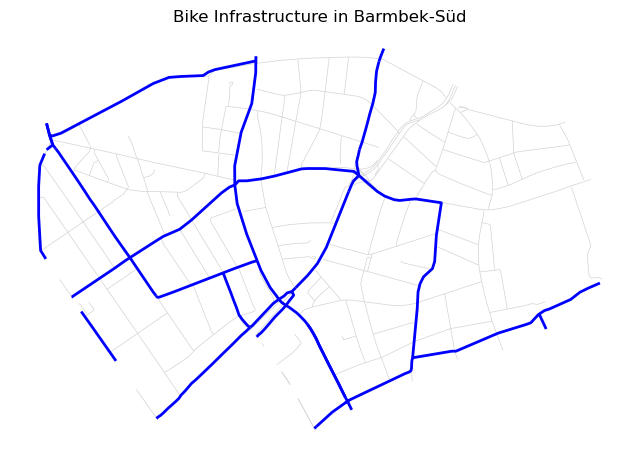

In [70]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

gdf_streets.plot(ax=ax, color="lightgrey", linewidth=0.5)
gdf_bike.plot(ax=ax, color="blue", linewidth=2)

plt.title("Bike Infrastructure in Barmbek-Süd")
plt.axis("off")

(np.float64(10.017142103886455),
 np.float64(10.058712075899383),
 np.float64(53.5691038859634),
 np.float64(53.58584660572898))

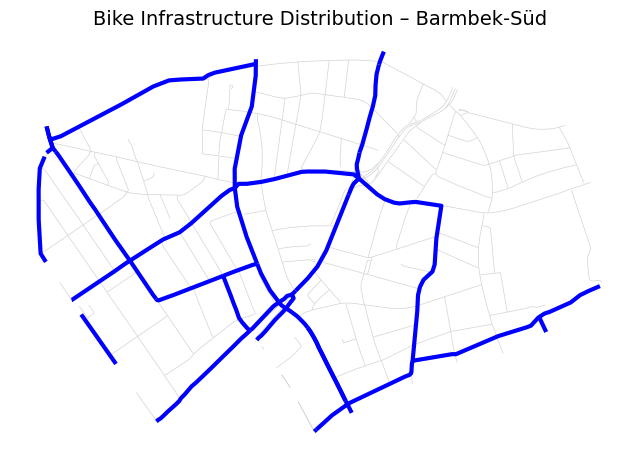

In [71]:
fig, ax = plt.subplots(figsize=(8, 8))

gdf_streets.plot(ax=ax, color="lightgrey", linewidth=0.5)
gdf_bike.plot(ax=ax, color="blue", linewidth=3)

plt.title("Bike Infrastructure Distribution – Barmbek-Süd", fontsize=14)
plt.axis("off")

# Interaktive echte Karte laden

In [72]:
m = gdf_bike.explore()

m.save("../outputs/bike_map_barmbek.html")

In [73]:
import os
print(os.path.abspath("../outputs/bike_map_barmbek.html"))

/Users/nicolebrueggmann/Desktop/DA_Capstone_Project_Nicole/Walkability-Barmbek-Sued_Hamburg/outputs/bike_map_barmbek.html


In [74]:
import webbrowser
webbrowser.open(os.path.abspath("../outputs/bike_map_barmbek.html"))

True

# Fahrradwege und Straßen ohne interaktive Karte laden

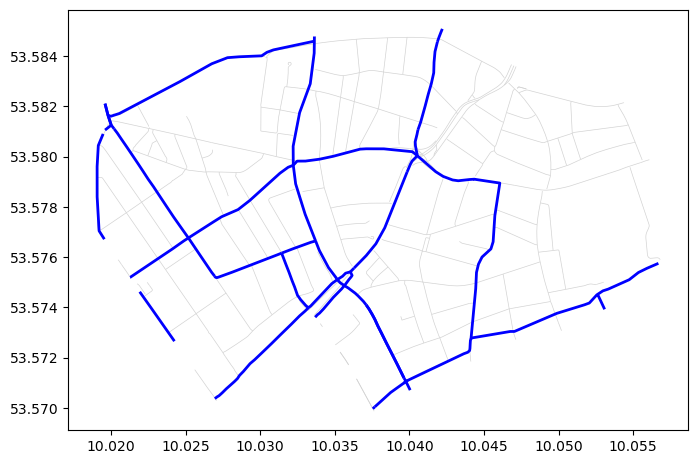

In [75]:
fig, ax = plt.subplots(figsize=(8, 8))

gdf_streets.plot(ax=ax, color="lightgrey", linewidth=0.5)
gdf_bike.plot(ax=ax, color="blue", linewidth=2)

plt.savefig("bike_map.png", dpi=300, bbox_inches="tight")

In [76]:
import os
print(os.getcwd())

/Users/nicolebrueggmann/Desktop/DA_Capstone_Project_Nicole/Walkability-Barmbek-Sued_Hamburg/notebooks


In [77]:
df_geo = pd.DataFrame([walkability])
df_final = df_geo.merge(df_excel, on="district")

NameError: name 'df_excel' is not defined